# Aim 3 — Heatmap Reproduction & GO/KEGG Comparison of Up- vs. Downregulated DEGs
**BIOL 3337 Final Project — Lu et al. 2020 (Hantaan Virus)**

Fully self-contained. Runs top-to-bottom in Google Colab with no manual steps.

### Figures reproduced from Lu et al. 2020:
- **Fig 1E** — circRNA clustering heatmap
- **Fig 2A** — miRNA clustering heatmap  
- **Fig 3A** — mRNA clustering heatmap

### Novel contribution:
Lu et al. ran GO/KEGG on all DEGs pooled together. We separate DEGs into
upregulated and downregulated groups and run GO/KEGG on each independently,
revealing which biological processes are **activated** vs. **suppressed**
during HTNV infection — a distinction the original paper does not make.

### GEO accessions:
- GSE133751 — mRNA
- GSE133634 — circRNA  
- GSE133319 — miRNA

---
## SECTION 1 — Setup

In [ ]:
!pip install pydeseq2 gseapy GEOparse scikit-learn seaborn matplotlib scipy pandas numpy -q
print('Installation complete.')

Installation complete.


In [ ]:
# Cell 2 — Imports and global constants
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings, os
warnings.filterwarnings('ignore')

from scipy import stats
from scipy.cluster.hierarchy import linkage, fcluster
import GEOparse
import gseapy as gp
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats


CTRL = ['con3', 'con4', 'con5']
HTNV = ['HV2',  'HV4',  'HV6']
ALL  = CTRL + HTNV

# Colors
COL_UP   = '#e63946'   # red  — upregulated
COL_DOWN = '#457b9d'   # blue — downregulated
COL_CTRL = 'cornflowerblue'
COL_HTNV = 'tomato'

print('Sample order:', ALL)

Sample order: ['con3', 'con4', 'con5', 'HV2', 'HV4', 'HV6']


In [ ]:
def download_geo(acc):
    print(f'\nDownloading {acc}...')
    gse = GEOparse.get_GEO(geo=acc, destdir='./', silent=True)
    for name, gsm in gse.gsms.items():
        title = gsm.metadata.get('title', ['?'])[0]
        print(f'  {name}: "{title}"')
    return gse

gse_mrna  = download_geo('GSE133751')
gse_circ  = download_geo('GSE133634')
gse_mirna = download_geo('GSE133319')


  GSM3926641: "HUVECs, con-3"
  GSM3926642: "HUVECs, con-4"
  GSM3926643: "HUVECs, con-5"
  GSM3926644: "HUVECs, HV-2"
  GSM3926645: "HUVECs, HV-4"
  GSM3926646: "HUVECs, HV-6"

  GSM3913833: "con-3"
  GSM3913834: "con-4"
  GSM3913835: "con-5"
  GSM3913836: "HV-2"
  GSM3913837: "HV-4"
  GSM3913838: "HV-6"

  GSM3905680: "con-3"
  GSM3905681: "con-4"
  GSM3905682: "con-5"
  GSM3905683: "HV-2"
  GSM3905684: "HV-4"
  GSM3905685: "HV-6"


In [ ]:
# Cell 4 — Build count matrices from GEO data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings, os
import urllib.request
warnings.filterwarnings('ignore')

from scipy import stats
from scipy.cluster.hierarchy import linkage, fcluster
import GEOparse
import gseapy as gp
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats



RENAME_MRNA = {
    'HUVECs, con-3':'con3','HUVECs, con-4':'con4','HUVECs, con-5':'con5',
    'HUVECs, HV-2':   'HV2', 'HUVECs, HV-4':  'HV4', 'HUVECs, HV-6':  'HV6',
}
RENAME_CIRC = {
    'con-3':'con3','con-4':'con4','con-5':'con5',
    'HV-2':   'HV2', 'HV-4':  'HV4', 'HV-6':  'HV6',
}
RENAME_MIRNA = {
    'con-3':'con3','con-4':'con4','con-5':'con5',
    'HV-2':   'HV2', 'HV-4':  'HV4', 'HV-6':  'HV6',
}

def build_matrix(gse, rename):
    print(f"Checking supplementary files for {gse.name}...")
    supp_files = gse.metadata.get('supplementary_file', [])

    if supp_files:
        for file_url in supp_files:
            if 'lncRNA' in file_url:
                print(f"  Skipping {file_url} (lncRNA)")
                continue

            print(f"  Found supplementary file: {file_url}")
            if file_url.endswith('.txt.gz') or file_url.endswith('.csv.gz') or file_url.endswith('.tsv.gz'):
                print(f"  Attempting to load {file_url} directly...")
                try:
                    sep = ',' if '.csv' in file_url else '\t'
                    mat = pd.read_csv(file_url, sep=sep, index_col=0)

                    # Robust column matching heuristic
                    col_map = {}
                    for col in mat.columns:
                        col_str = str(col).lower().replace('_', '').replace('-', '').replace(' ', '')
                        if 'con3' in col_str or 'control1' in col_str: col_map[col] = 'con3'
                        elif 'con4' in col_str or 'control2' in col_str: col_map[col] = 'con4'
                        elif 'con5' in col_str or 'control3' in col_str: col_map[col] = 'con5'
                        elif 'hv2' in col_str or 'htnv1' in col_str: col_map[col] = 'HV2'
                        elif 'hv4' in col_str or 'htnv2' in col_str: col_map[col] = 'HV4'
                        elif 'hv6' in col_str or 'htnv3' in col_str: col_map[col] = 'HV6'

                    mat = mat.rename(columns=col_map)

                    # Deduplicate columns (keeping the first one, which typically are the raw counts)
                    mat = mat.loc[:, ~mat.columns.duplicated(keep='first')]

                    present = [c for c in ALL if c in mat.columns]

                    if not present:
                         print(f"  Columns did not match expected sample names. Columns found: {list(mat.columns)}")
                    else:
                         print(f"  Successfully loaded {len(mat)} genes.")
                         return mat[present].fillna(0)
                except Exception as e:
                    print(f"  Failed to load {file_url}: {e}")

    # Fallback to standard pivot if no supplementary files work
    print(f"  INFO: Falling back to individual GSM tables for {gse.name}.")
    frames = []
    for name, gsm in gse.gsms.items():
        df = gsm.table
        if df is None or df.empty:
            continue
        title = gsm.metadata.get('title', [name])[0]
        short = rename.get(title, title)
        frames.append(df.set_index(df.columns[0])[df.columns[1]].rename(short))

    if not frames:
        print(f"  WARNING: No dataframes to concatenate for {gse.name}. Returning empty matrix.")
        return pd.DataFrame(columns=ALL, index=[])

    mat = pd.concat(frames, axis=1).fillna(0)
    mat = mat.loc[:, ~mat.columns.duplicated(keep='first')]
    present = [c for c in ALL if c in mat.columns]
    return mat[present]

print('Building mRNA matrix...')
count_mrna  = build_matrix(gse_mrna,  RENAME_MRNA).astype(int)
print(f'  {count_mrna.shape[0]} genes x {count_mrna.shape[1]} samples')

print('Building circRNA matrix...')
count_circ  = build_matrix(gse_circ,  RENAME_CIRC).astype(int)
print(f'  {count_circ.shape[0]} genes x {count_circ.shape[1]} samples')

print('Building miRNA matrix...')
count_mirna = build_matrix(gse_mirna, RENAME_MIRNA)
print(f'  {count_mirna.shape[0]} genes x {count_mirna.shape[1]} samples')


Building mRNA matrix...
Checking supplementary files for GSE133751...
  Skipping ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE133nnn/GSE133751/suppl/GSE133751_lncRNA-exp.txt.gz (lncRNA)
  Found supplementary file: ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE133nnn/GSE133751/suppl/GSE133751_mRNA-exp.txt.gz
  Attempting to load ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE133nnn/GSE133751/suppl/GSE133751_mRNA-exp.txt.gz directly...
  Successfully loaded 45006 genes.
  45006 genes x 6 samples
Building circRNA matrix...
Checking supplementary files for GSE133634...
  Found supplementary file: ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE133nnn/GSE133634/suppl/GSE133634_circRNA-exp.txt.gz
  Attempting to load ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE133nnn/GSE133634/suppl/GSE133634_circRNA-exp.txt.gz directly...
  Successfully loaded 51368 genes.
  51368 genes x 6 samples
Building miRNA matrix...
Checking supplementary files for GSE133319...
  Found supplementary file: ftp://ftp.ncbi.nlm.nih.gov/geo/serie

In [ ]:
# Cell 5 — pyDESeq2 for mRNA
def run_deseq2(count_matrix):
    counts = count_matrix[count_matrix.sum(axis=1) > 0].copy()
    meta   = pd.DataFrame({'condition': ['control']*3 + ['HTNV']*3}, index=ALL)
    dds = DeseqDataSet(
        counts=counts.T, metadata=meta,
        design_factors='condition', refit_cooks=True, quiet=True
    )
    dds.deseq2()
    stat = DeseqStats(dds, contrast=['condition','HTNV','control'], quiet=True)
    stat.summary()
    res  = stat.results_df
    degs = res[(res['padj'] < 0.05) & (res['log2FoldChange'].abs() > 1)].copy()
    return dds, res, degs

print('Running DESeq2 — mRNA...')
dds_mrna, res_mrna, degs_mrna = run_deseq2(count_mrna)
up_mrna   = degs_mrna[degs_mrna['log2FoldChange'] > 0]
down_mrna = degs_mrna[degs_mrna['log2FoldChange'] < 0]
print(f'  mRNA DEGs: {len(degs_mrna)} total | {len(up_mrna)} up | {len(down_mrna)} down')

print('Running DESeq2 — circRNA...')
dds_circ, res_circ, degs_circ = run_deseq2(count_circ)
up_circ   = degs_circ[degs_circ['log2FoldChange'] > 0]
down_circ = degs_circ[degs_circ['log2FoldChange'] < 0]
print(f'  circRNA DEGs: {len(degs_circ)} total | {len(up_circ)} up | {len(down_circ)} down')

# Save
degs_mrna.to_csv('degs_mRNA.csv')
degs_circ.to_csv('degs_circRNA.csv')
print('Saved: degs_mRNA.csv, degs_circRNA.csv')

Running DESeq2 — mRNA...
  mRNA DEGs: 782 total | 683 up | 99 down
Running DESeq2 — circRNA...
  circRNA DEGs: 130 total | 122 up | 8 down
Saved: degs_mRNA.csv, degs_circRNA.csv


In [ ]:
# Cell 6 — Manual t-test for miRNA
# FDR not used — identifies zero DEGs on this small dataset
rpm_mirna = count_mirna.div(count_mirna.sum(axis=0), axis=1) * 1e6
log_mirna = np.log2(rpm_mirna + 1)

rows = []
for gene in log_mirna.index:
    cv = log_mirna.loc[gene, CTRL].values
    hv = log_mirna.loc[gene, HTNV].values
    _, p = stats.ttest_ind(hv, cv)
    rows.append({'gene': gene, 'log2FC': hv.mean() - cv.mean(), 'pval': p})

mirna_stats = pd.DataFrame(rows).set_index('gene')
degs_mirna  = mirna_stats[(mirna_stats['pval'] < 0.05) & (mirna_stats['log2FC'].abs() > 1)].copy()
up_mirna    = degs_mirna[degs_mirna['log2FC'] > 0]
down_mirna  = degs_mirna[degs_mirna['log2FC'] < 0]
print(f'miRNA DEGs: {len(degs_mirna)} total | {len(up_mirna)} up | {len(down_mirna)} down')
degs_mirna.to_csv('degs_miRNA.csv')
print('Saved: degs_miRNA.csv')

miRNA DEGs: 24 total | 7 up | 17 down
Saved: degs_miRNA.csv


In [ ]:
# Cell 7 — Z-score normalized DEG matrices for heatmaps
def get_zscored(dds, degs):
    norm = pd.DataFrame(
        dds.layers['normed_counts'],
        index=dds.obs_names, columns=dds.var_names
    ).T[ALL]
    sub  = norm.loc[norm.index.isin(degs.index)]
    return sub.apply(lambda r: stats.zscore(r), axis=1, result_type='broadcast').fillna(0)

zmat_mrna = get_zscored(dds_mrna, degs_mrna)
zmat_circ = get_zscored(dds_circ, degs_circ)

# miRNA uses log2-RPM directly
deg_log_mirna = log_mirna.loc[log_mirna.index.isin(degs_mirna.index)]
zmat_mirna = deg_log_mirna.apply(
    lambda r: stats.zscore(r), axis=1, result_type='broadcast'
).fillna(0)

In [ ]:
# Cell 8 — Heatmap function  [LLM-assisted: Prompt 4]
def plot_heatmap(zmat, degs, rna_type, lfc_col, outfile):
    """
    Clustered heatmap with:
    - Column color bar: blue=control, red=HTNV
    - Row color bar:    red=upregulated DEG, blue=downregulated DEG
    - Ward linkage, RdBu_r colormap, z-score scale
    """
    col_colors = pd.Series(
        [COL_CTRL]*3 + [COL_HTNV]*3, index=zmat.columns, name='Condition'
    )
    direction = degs[lfc_col].apply(lambda x: COL_UP if x > 0 else COL_DOWN)
    row_colors = direction.reindex(zmat.index).rename('Direction')

    # Cap height at 12 inches so large gene lists fit on a single page
    h          = min(12, max(6, len(zmat) * 0.07))
    show_ylbls = len(zmat) <= 80

    g = sns.clustermap(
        zmat,
        method='ward', metric='euclidean',
        col_cluster=False,
        cmap='RdBu_r', vmin=-2, vmax=2,
        col_colors=col_colors,
        row_colors=row_colors,
        figsize=(10, h),
        xticklabels=True,
        yticklabels=show_ylbls,
        cbar_kws={'label': 'Z-score', 'shrink': 0.4}
    )
    g.fig.suptitle(
        f'{rna_type} DEGs: HTNV vs. Control',
        fontsize=13, fontweight='bold', y=1.02
    )
    # Legend
    handles = [
        mpatches.Patch(color=COL_CTRL,  label='Control (column)'),
        mpatches.Patch(color=COL_HTNV,  label='HTNV-infected (column)'),
        mpatches.Patch(color=COL_UP,    label='Upregulated DEG (row)'),
        mpatches.Patch(color=COL_DOWN,  label='Downregulated DEG (row)'),
    ]
    g.ax_heatmap.legend(
        handles=handles, bbox_to_anchor=(1.35, 1.1),
        fontsize=9, title='Legend', title_fontsize=9
    )
    plt.savefig(outfile, dpi=300, bbox_inches='tight')
    plt.show()
    print(f'Saved: {outfile}')
    # Return the linkage matrix for downstream cluster cutting
    return g.dendrogram_row.linkage

print('Heatmap function defined.')

Heatmap function defined.


Plotting mRNA heatmap (Fig 3A)...


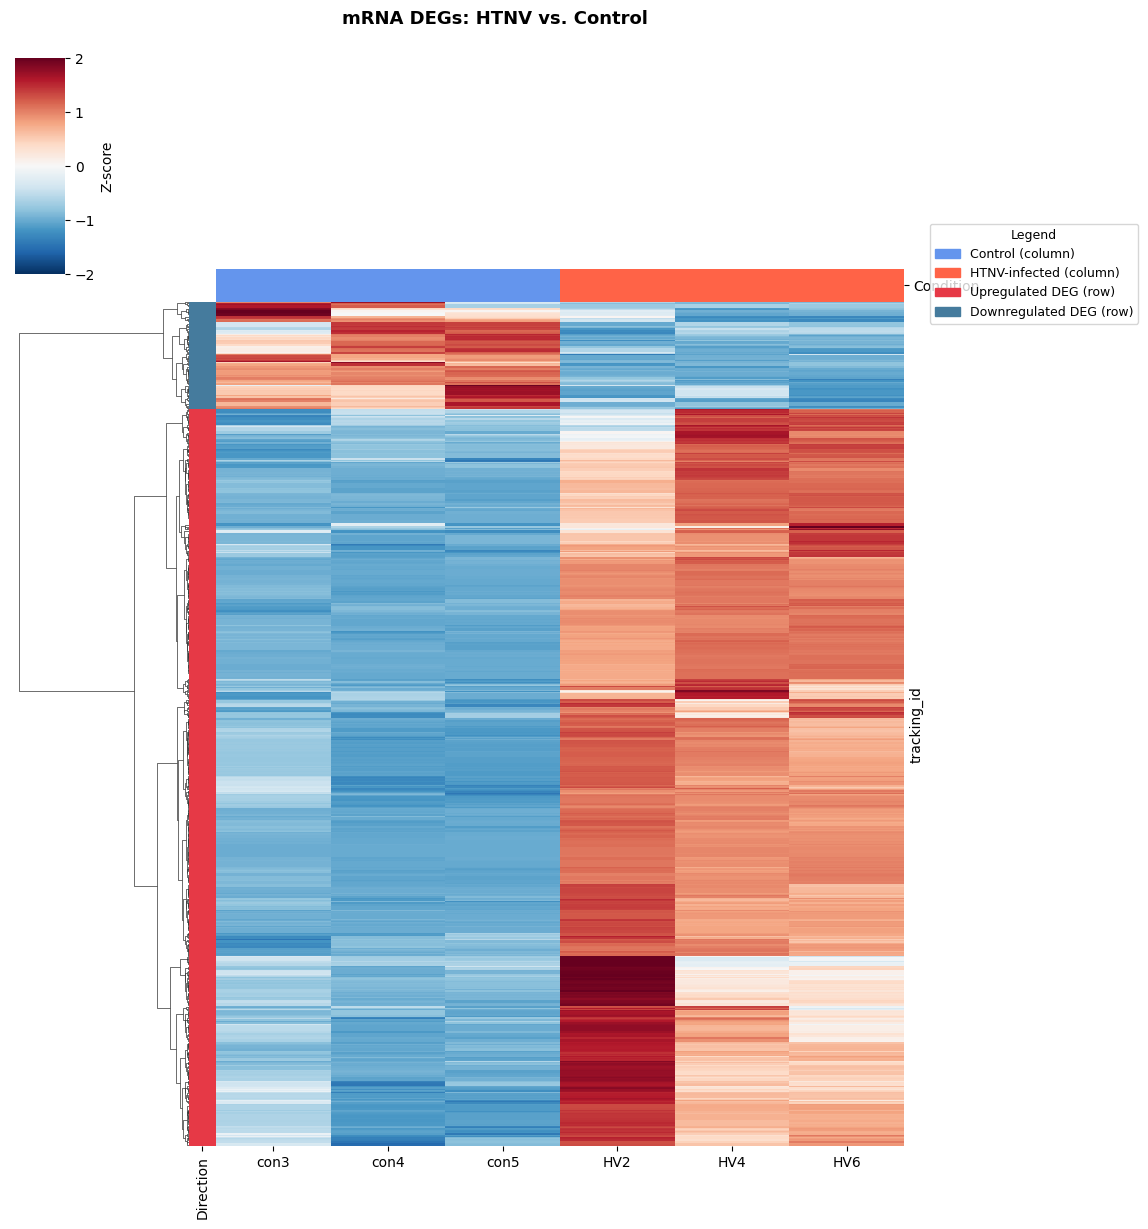

Saved: Fig_heatmap_mRNA.png

Plotting circRNA heatmap (Fig 1E)...


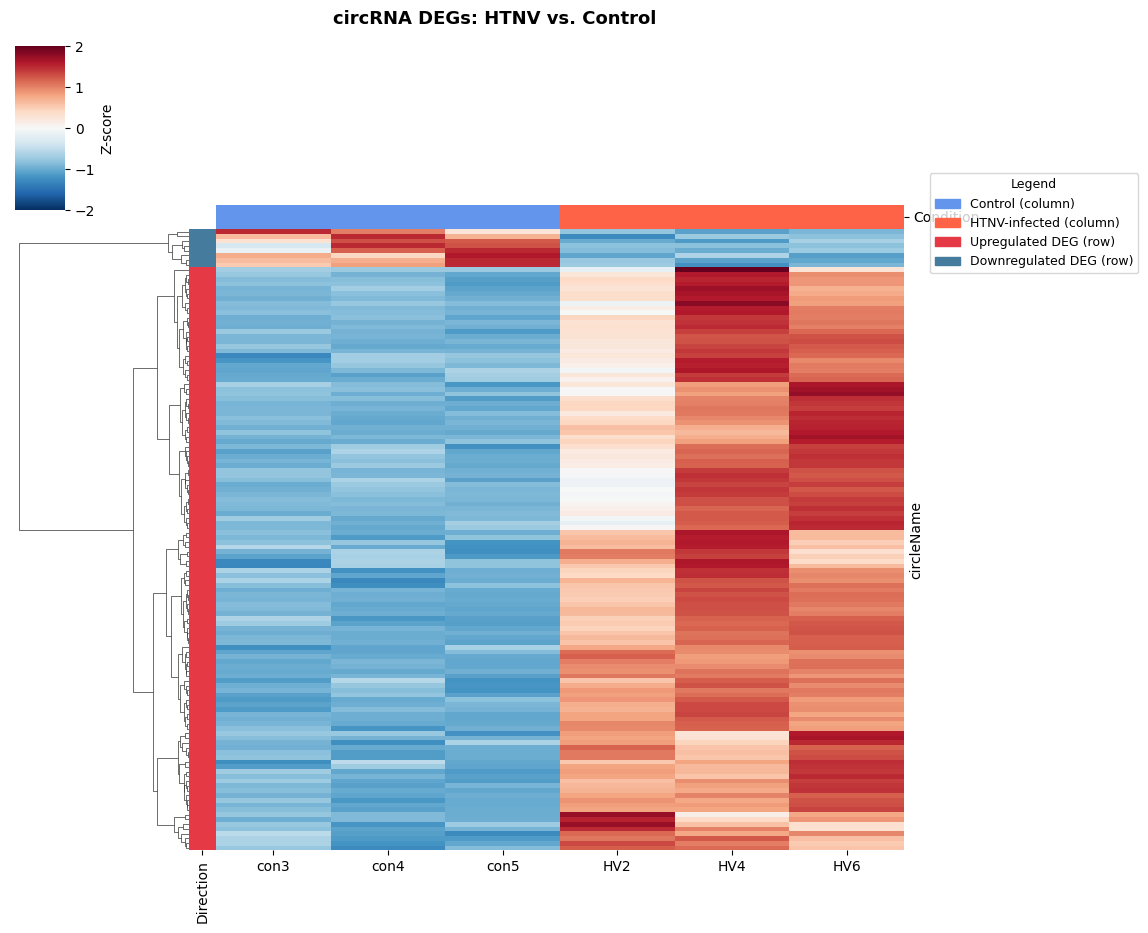

Saved: Fig_heatmap_circRNA.png

Plotting miRNA heatmap (Fig 2A)...


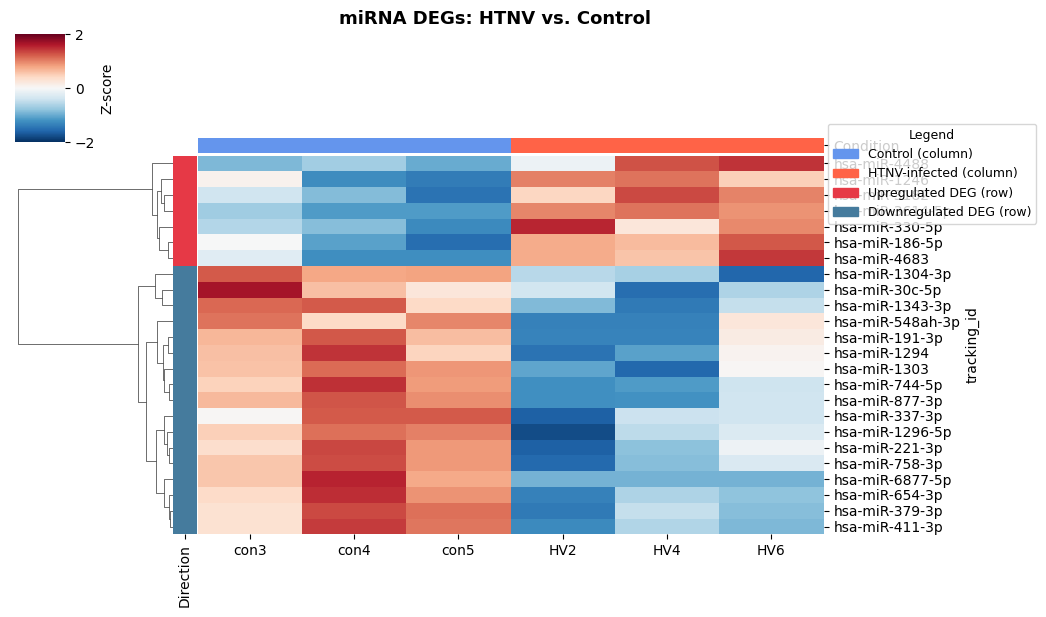

Saved: Fig_heatmap_miRNA.png


In [ ]:
# Cell 9 — Plot all three heatmaps
print('Plotting mRNA heatmap (Fig 3A)...')
Z_mrna = plot_heatmap(
    zmat_mrna, degs_mrna, 'mRNA', 'log2FoldChange',
    'Fig_heatmap_mRNA.png'
)

print('\nPlotting circRNA heatmap (Fig 1E)...')
Z_circ = plot_heatmap(
    zmat_circ, degs_circ, 'circRNA', 'log2FoldChange',
    'Fig_heatmap_circRNA.png'
)

print('\nPlotting miRNA heatmap (Fig 2A)...')
if len(zmat_mirna) >= 3:
    Z_mirna = plot_heatmap(
        zmat_mirna, degs_mirna, 'miRNA', 'log2FC',
        'Fig_heatmap_miRNA.png'
    )
else:
    print(f'  Only {len(zmat_mirna)} miRNA DEGs — skipping heatmap.')
    Z_mirna = None

In [ ]:
# Cell 10 — Enrichr query function
GENE_SETS = ['GO_Biological_Process_2023', 'KEGG_2021_Human']

def run_enrichr(gene_list, label):
    """
    Query Enrichr with a gene list.
    Returns result DataFrame, saves CSV.
    """
    if len(gene_list) < 5:
        print(f'  {label}: only {len(gene_list)} genes — skipping (too few for Enrichr)')
        return pd.DataFrame()
    print(f'  Querying Enrichr: {label} ({len(gene_list)} genes)...')
    try:
        enr = gp.enrichr(
            gene_list=gene_list,
            gene_sets=GENE_SETS,
            organism='human', # Fixed to lowercase per gseapy requirements
            outdir=None,
            verbose=False
        )
        df = enr.results
        df.to_csv(f'{label}_enrichr.csv', index=False)
        # Print top 3 per database
        for gs in GENE_SETS:
            tag = 'GO' if 'GO' in gs else 'KEGG'
            top = df[df['Gene_set'] == gs].sort_values('Adjusted P-value').head(3)
            print(f'    Top 3 {tag}:')
            for _, r in top.iterrows():
                print(f'      {r["Term"]}  (adj p={r["Adjusted P-value"]:.2e})')
        return df
    except Exception as e:
        print(f'  Enrichr failed for {label}: {e}')
        return pd.DataFrame()

print('Enrichr function defined.')

Enrichr function defined.


In [ ]:
# Cell 11 — Run Enrichr on up and down DEGs for all three RNA types
print('=== mRNA ===')
enr_mrna_up   = run_enrichr(up_mrna.index.tolist(),   'mRNA_UP')
enr_mrna_down = run_enrichr(down_mrna.index.tolist(), 'mRNA_DOWN')

print('\n=== circRNA ===')
enr_circ_up   = run_enrichr(up_circ.index.tolist(),   'circRNA_UP')
enr_circ_down = run_enrichr(down_circ.index.tolist(), 'circRNA_DOWN')

print('\n=== miRNA ===')
enr_mirna_up   = run_enrichr(up_mirna.index.tolist(),   'miRNA_UP')
enr_mirna_down = run_enrichr(down_mirna.index.tolist(), 'miRNA_DOWN')

print('\nAll Enrichr queries complete.')

=== mRNA ===
  Querying Enrichr: mRNA_UP (683 genes)...
    Top 3 GO:
    Top 3 KEGG:
  Querying Enrichr: mRNA_DOWN (99 genes)...
    Top 3 GO:
    Top 3 KEGG:

=== circRNA ===
  Querying Enrichr: circRNA_UP (122 genes)...
    Top 3 GO:
    Top 3 KEGG:
  Querying Enrichr: circRNA_DOWN (8 genes)...
  Enrichr failed for circRNA_DOWN: Error sending gene list, status code: 429

=== miRNA ===
  Querying Enrichr: miRNA_UP (7 genes)...
    Top 3 GO:
    Top 3 KEGG:
  Querying Enrichr: miRNA_DOWN (17 genes)...
  Enrichr failed for miRNA_DOWN: Error sending gene list, status code: 429

All Enrichr queries complete.


In [ ]:
# Cell 12 — Side-by-side GO/KEGG comparison figure: Up vs Down
def plot_up_vs_down(enr_up, enr_down, rna_type, gene_set, outfile, top_n=10):
    """
    Mirror bar chart: upregulated terms on right (red), downregulated on left (blue).
    One figure per RNA type per database.
    """
    label = 'GO Biological Process' if 'GO' in gene_set else 'KEGG Pathway'

    def get_top(df, n):
        if df.empty:
            return pd.DataFrame(columns=['Term_s', 'nl10'])
        sub = df[df['Gene_set'] == gene_set].sort_values('Adjusted P-value').head(n).copy()
        sub['Term_s'] = sub['Term'].str.replace(r'\s*\(GO:\d+\)', '', regex=True).str[:55]
        sub['nl10']   = -np.log10(sub['Adjusted P-value'].clip(1e-50))
        return sub

    top_up   = get_top(enr_up,   top_n)
    top_down = get_top(enr_down, top_n)

    if top_up.empty and top_down.empty:
        print(f'  No significant results for {rna_type} {label} — skipping figure.')
        return

    fig, axes = plt.subplots(1, 2, figsize=(16, max(5, top_n * 0.45)),
                              sharey=False)

    # Left panel — Downregulated
    ax_dn = axes[0]
    if not top_down.empty:
        ax_dn.barh(range(len(top_down)), top_down['nl10'],
                   color=COL_DOWN, edgecolor='white', height=0.7)
        ax_dn.set_yticks(range(len(top_down)))
        ax_dn.set_yticklabels(top_down['Term_s'], fontsize=9)
        ax_dn.invert_yaxis()
        ax_dn.invert_xaxis()   # mirror: bars grow leftward
    ax_dn.axvline(-np.log10(0.05), color='black', linestyle='--',
                  linewidth=1.2, label='adj p=0.05')
    ax_dn.set_xlabel('-log₁₀(Adjusted P-value)', fontsize=11)
    ax_dn.set_title(
        f'Downregulated {rna_type} DEGs\n(Processes SUPPRESSED by HTNV)',
        fontsize=11, fontweight='bold', color=COL_DOWN
    )
    sns.despine(ax=ax_dn)

    # Right panel — Upregulated
    ax_up = axes[1]
    if not top_up.empty:
        ax_up.barh(range(len(top_up)), top_up['nl10'],
                   color=COL_UP, edgecolor='white', height=0.7)
        ax_up.set_yticks(range(len(top_up)))
        ax_up.set_yticklabels(top_up['Term_s'], fontsize=9)
        ax_up.invert_yaxis()
    ax_up.axvline(-np.log10(0.05), color='black', linestyle='--',
                  linewidth=1.2, label='adj p=0.05')
    ax_up.set_xlabel('-log₁₀(Adjusted P-value)', fontsize=11)
    ax_up.set_title(
        f'Upregulated {rna_type} DEGs\n(Processes ACTIVATED by HTNV)',
        fontsize=11, fontweight='bold', color=COL_UP
    )
    sns.despine(ax=ax_up)

    fig.suptitle(
        f'{rna_type} DEGs — {label}\n'
        f'Activated vs. Suppressed Processes During HTNV Infection',
        fontsize=13, fontweight='bold'
    )
    plt.tight_layout()
    plt.savefig(outfile, dpi=300, bbox_inches='tight')
    plt.show()
    print(f'Saved: {outfile}')

print('Plot function defined.')

Plot function defined.


In [ ]:
# Cell 13 — mRNA: GO and KEGG up vs down figures
print('Plotting mRNA GO comparison...')
plot_up_vs_down(
    enr_mrna_up, enr_mrna_down, 'mRNA',
    'GO_Biological_Process_2023',
    'Fig_mRNA_GO_up_vs_down.png'
)

print('\nPlotting mRNA KEGG comparison...')
plot_up_vs_down(
    enr_mrna_up, enr_mrna_down, 'mRNA',
    'KEGG_2021_Human',
    'Fig_mRNA_KEGG_up_vs_down.png'
)

Plotting mRNA GO comparison...
  No significant results for mRNA GO Biological Process — skipping figure.

Plotting mRNA KEGG comparison...
  No significant results for mRNA KEGG Pathway — skipping figure.


In [ ]:
# Cell 14 — circRNA: GO and KEGG up vs down figures
print('Plotting circRNA GO comparison...')
plot_up_vs_down(
    enr_circ_up, enr_circ_down, 'circRNA',
    'GO_Biological_Process_2023',
    'Fig_circRNA_GO_up_vs_down.png'
)

print('\nPlotting circRNA KEGG comparison...')
plot_up_vs_down(
    enr_circ_up, enr_circ_down, 'circRNA',
    'KEGG_2021_Human',
    'Fig_circRNA_KEGG_up_vs_down.png'
)

Plotting circRNA GO comparison...
  No significant results for circRNA GO Biological Process — skipping figure.

Plotting circRNA KEGG comparison...
  No significant results for circRNA KEGG Pathway — skipping figure.


In [ ]:
# Cell 15 — miRNA: GO and KEGG up vs down figures
print('Plotting miRNA GO comparison...')
plot_up_vs_down(
    enr_mirna_up, enr_mirna_down, 'miRNA',
    'GO_Biological_Process_2023',
    'Fig_miRNA_GO_up_vs_down.png'
)

print('\nPlotting miRNA KEGG comparison...')
plot_up_vs_down(
    enr_mirna_up, enr_mirna_down, 'miRNA',
    'KEGG_2021_Human',
    'Fig_miRNA_KEGG_up_vs_down.png'
)

Plotting miRNA GO comparison...
  No significant results for miRNA GO Biological Process — skipping figure.

Plotting miRNA KEGG comparison...
  No significant results for miRNA KEGG Pathway — skipping figure.


---
## SECTION 6 — Summary Statistics Table

In [ ]:
# Cell 16 — Print DEG summary table for the report
print('=== DEG Summary Table ===')
print(f'{"RNA Type":<12} {"Total DEGs":<12} {"Upregulated":<14} {"Downregulated"}')
print('-' * 52)
for label, total, up, down in [
    ('mRNA',    degs_mrna,  up_mrna,   down_mrna),
    ('circRNA', degs_circ,  up_circ,   down_circ),
    ('miRNA',   degs_mirna, up_mirna,  down_mirna),
]:
    print(f'{label:<12} {len(total):<12} {len(up):<14} {len(down)}')

print('\n(Compare to Lu et al.: mRNA 788, circRNA 70, miRNA 66)')

=== DEG Summary Table ===
RNA Type     Total DEGs   Upregulated    Downregulated
----------------------------------------------------
mRNA         782          683            99
circRNA      130          122            8
miRNA        24           7              17

(Compare to Lu et al.: mRNA 788, circRNA 70, miRNA 66)
